# Fake News Detection using Machine Learning (with EDA)

In [1]:
# Import libraries
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [6]:
# Load dataset
df = pd.read_csv("C:\\Users\\Harsha\\Desktop\\files\\project\\sample_fake_news_200.csv")
df.head(10)

,title,text,label
0,News Headline 1,This is the content of news article number 1. ...,FAKE
1,News Headline 2,This is the content of news article number 2. ...,REAL
2,News Headline 3,This is the content of news article number 3. ...,REAL
3,News Headline 4,This is the content of news article number 4. ...,FAKE
4,News Headline 5,This is the content of news article number 5. ...,REAL
5,News Headline 6,This is the content of news article number 6. ...,FAKE
6,News Headline 7,This is the content of news article number 7. ...,FAKE
7,News Headline 8,This is the content of news article number 8. ...,REAL
8,News Headline 9,This is the content of news article number 9. ...,FAKE
9,News Headline 10,This is the content of news article number 10....,FAKE


## Exploratory Data Analysis (EDA)

In [7]:
# 1. Class distribution
df['label'].value_counts()

label
FAKE    104
REAL     96
Name: count, dtype: int64

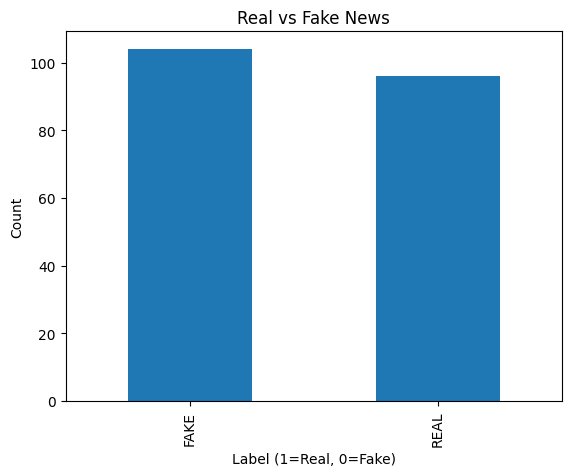

In [8]:
# 2. Plot class distribution
df['label'].value_counts().plot(kind='bar')
plt.title("Real vs Fake News")
plt.xlabel("Label (1=Real, 0=Fake)")
plt.ylabel("Count")
plt.show()

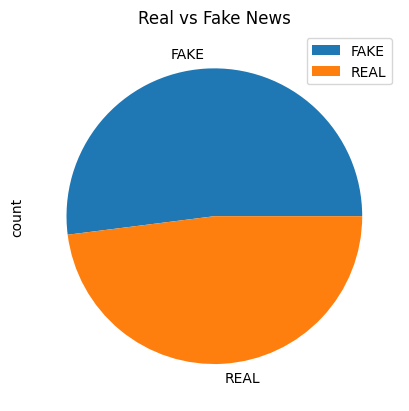

In [ ]:

df['label'].value_counts().plot(kind='pie')
plt.title("Real vs Fake News")

plt.legend()
plt.show()

C:\Users\Harsha\AppData\Local\Temp\ipykernel_9984\487731393.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


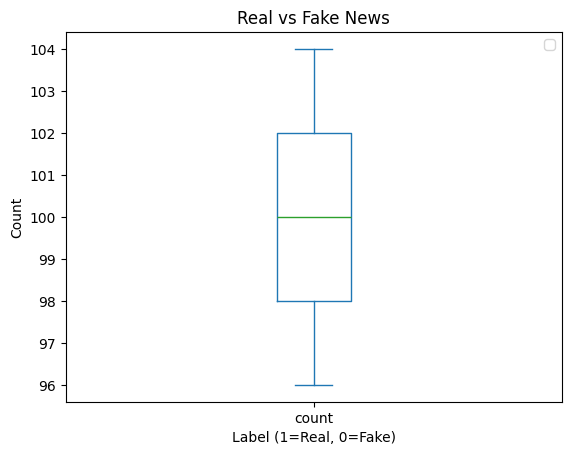

In [ ]:
df['label'].value_counts().plot(kind='box')
plt.title("Real vs Fake News")
plt.xlabel("Label (1=Real, 0=Fake)")
plt.ylabel("Count")
plt.show()

In [9]:
# 3. Text length analysis
df['text_length'] = df['text'].apply(len)
df.groupby('label')['text_length'].mean()

label
FAKE    89.480769
REAL    89.437500
Name: text_length, dtype: float64

In [10]:
# 4. Most common words
from collections import Counter

all_words = " ".join(df['text']).lower().split()
Counter(all_words).most_common(10)

[('this', 200),
 ('is', 200),
 ('the', 200),
 ('content', 200),
 ('of', 200),
 ('news', 200),
 ('article', 200),
 ('number', 200),
 ('it', 200),
 ('contains', 200)]

## Data Preprocessing

In [19]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(preprocess)
df.head()

,title,text,label,text_length,clean_text
0,News Headline 1,This is the content of news article number 1. ...,FAKE,88,content news articl number contain sampl text ...
1,News Headline 2,This is the content of news article number 2. ...,REAL,88,content news articl number contain sampl text ...
2,News Headline 3,This is the content of news article number 3. ...,REAL,88,content news articl number contain sampl text ...
3,News Headline 4,This is the content of news article number 4. ...,FAKE,88,content news articl number contain sampl text ...
4,News Headline 5,This is the content of news article number 5. ...,REAL,88,content news articl number contain sampl text ...


In [20]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

In [21]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.45
              precision    recall  f1-score   support

        FAKE       0.45      1.00      0.62        18
        REAL       0.00      0.00      0.00        22

    accuracy                           0.45        40
   macro avg       0.23      0.50      0.31        40
weighted avg       0.20      0.45      0.28        40



c:\Users\Harsha\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Harsha\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Harsha\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [23]:
# Prediction function
def predict_news(text):
    text = preprocess(text)
    vector = vectorizer.transform([text])
    prediction = model.predict(vector)
    return "REAL NEWS" if prediction[0] == 1 else "FAKE NEWS"

print(predict_news("NASA launches new satellite"))

FAKE NEWS
